<a href="https://colab.research.google.com/github/Fjmoya-uba/Taller-Procesamiento-Se-ales/blob/main/TPs/TPS_02.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Trabajo Práctico N°2 de TPS: Regresión Polinómica

## Ítem A

### Punto 1


Preparación del entorno de programación.

In [9]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.preprocessing import OneHotEncoder, PolynomialFeatures, StandardScaler
from sklearn.compose import ColumnTransformer

Carga de la base de datos y comprobación de los mismos.

In [10]:
# Cargar la base de datos
df = sns.load_dataset('healthexp')
df

,Year,Country,Spending_USD,Life_Expectancy
0,1970,Germany,252.311,70.6
1,1970,France,192.143,72.2
2,1970,Great Britain,123.993,71.9
3,1970,Japan,150.437,72.0
4,1970,USA,326.961,70.9
...,...,...,...,...
269,2020,Germany,6938.983,81.1
270,2020,France,5468.418,82.3
271,2020,Great Britain,5018.700,80.4
272,2020,Japan,4665.641,84.7


### Punto 2

A partir de estos datos extraídos, se analiza la relación entre el gasto público en salud per cápita y la esperanza de vida mediante un gráfico de dispersión. Cada punto representa un país en un determinado año, y se utiliza un color distinto para identificar a cada uno.

El objetivo es observar posibles patrones o correlaciones entre ambas variables, y comparar cómo se comportan los distintos países.

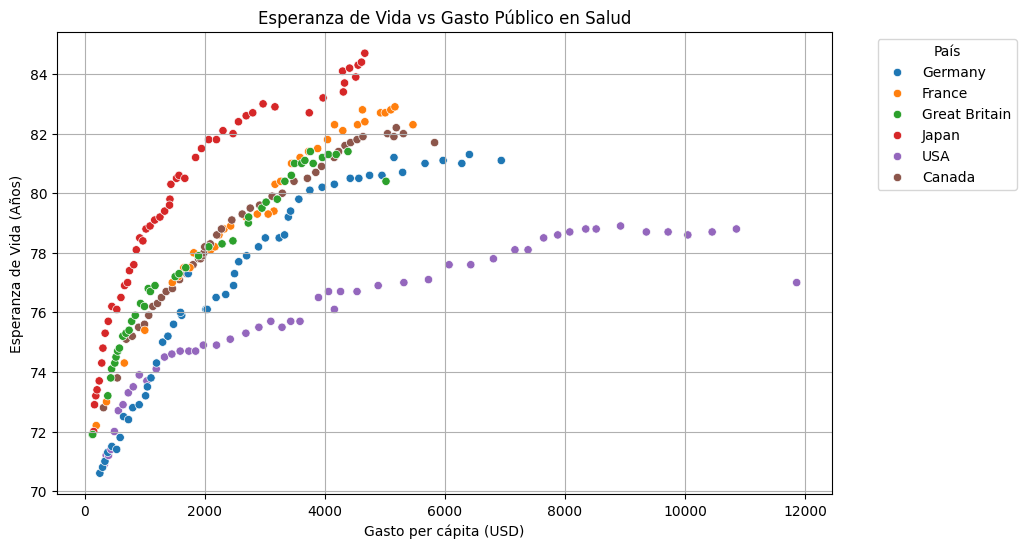

In [11]:
# Graficar scatter de esperanza de vida vs gasto público por país
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='Spending_USD', y='Life_Expectancy', hue='Country')
plt.title('Esperanza de Vida vs Gasto Público en Salud')
plt.xlabel('Gasto per cápita (USD)')
plt.ylabel('Esperanza de Vida (Años)')
plt.grid(True)
plt.legend(title='País', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()


A partir del gráfico se observa una relación creciente entre el gasto público en salud per cápita y la expectativa de vida. En términos generales, mayores niveles de gasto se asocian con mayores valores de longevidad.

Sin embargo, esta relación no es lineal. Para niveles bajos e intermedios de gasto, los incrementos generan mejoras relativamente significativas en la expectativa de vida. En cambio, a partir de aproximadamente 2008, varias curvas comienzan a aplanarse. Se observa que aumentos adicionales en el gasto se traducen en mejoras cada vez menores.

En los últimos años de la serie también se aprecia que, salvo en Japón, varios países incrementan su gasto mientras que la expectativa de vida se estanca o incluso disminuye levemente. Este comportamiento, particularmente visible en el último año de cada país, podría explicarse por el impacto de la pandemia de COVID-19, que habría elevado el gasto sanitario mientras aumentaba la mortalidad.

Por último, se evidencian diferencias entre países para niveles similares de gasto. En particular, Estados Unidos presenta niveles considerablemente más altos sin alcanzar las mayores expectativas de vida, mientras que Japón logra mejores resultados con menor gasto, lo que indica que la longevidad depende también de factores estructurales más allá de la inversión en salud.

### Punto 3

Los datos se dividieron en conjuntos de entrenamiento, validación y testeo utilizando un criterio temporal. A lo largo de este trabajo práctico, se entrenará al modelo con observaciones anteriores a 2008, se lo validará con los datos entre 2008 y 2015, y se evaluará su desempeño final con datos posteriores a 2015. Esta partición permite simular un escenario más realista, en el cual el modelo aprende a partir del pasado y se evalúa sobre años futuros.

In [12]:
# Definir conjuntos de entrenamiento, validación y testeo
# Entrenamiento: anterior al 2008
train_df = df[df['Year'] < 2008]

# Validación: entre 2008 y 2015 (inclusive)
val_df = df[(df['Year'] >= 2008) & (df['Year'] <= 2015)]

# Testeo: posteriores al 2015
test_df = df[df['Year'] > 2015]

# ¿Es necesario?
print(f"Registros - Train: {len(train_df)}, Val: {len(val_df)}, Test: {len(test_df)}")

Registros - Train: 196, Val: 48, Test: 30


## Ítem B

En este apartado se preparan los datos antes de entrenar el modelo. La idea es transformar las variables originales a una forma que el algoritmo pueda usar correctamente. En particular, se trabaja por un lado con la variable categórica `Country`, que debe convertirse en variables numéricas, y por otro lado con la variable de gasto, sobre la cual se busca construir una representación que permita capturar relaciones no lineales.

### Punto 1

La variable `Country` indica a qué país pertenece cada dato, pero como es una variable categórica, no se la puede usar directamente como un número. Por ejemplo, no tendría sentido decir que Japón vale 1, USA vale 2 y Alemania vale 3, porque eso haría parecer que hay un orden entre países, cuando en realidad no lo hay.

Para resolver esto se usa `OneHotEncoder`, que transforma cada país en una variable binaria. Es decir, para cada país se crea una columna que vale 1 si el dato pertenece a ese país y 0 si no pertenece.

Si hay \(K\) países distintos, entonces se generan \(K\) variables indicadoras. De esta forma, el modelo puede distinguir de qué país viene cada observación sin inventar relaciones de orden que no existen.

En este trabajo, esta transformación es útil porque en el gráfico se ve que, para niveles parecidos de gasto público en salud, no todos los países tienen exactamente la misma esperanza de vida. Entonces, codificar el país de esta manera permite que el modelo tenga en cuenta esas diferencias.

In [22]:
# Se define el codificador
encoder = OneHotEncoder(sparse_output=False) # sparse_output=False para ver la matriz fácilmente

# Ejemplo de funcionamiento (opcional para ver qué hace):
paises_encoded = encoder.fit_transform(train_df[['Country']])
nombres_columnas = encoder.get_feature_names_out(['Country'])

print("Nuevas columnas creadas:", nombres_columnas)
print("Ejemplo de las primeras filas:\n", paises_encoded[:5])

Nuevas columnas creadas: ['Country_Canada' 'Country_France' 'Country_Germany'
 'Country_Great Britain' 'Country_Japan' 'Country_USA']
Ejemplo de las primeras filas:
 [[0. 0. 1. 0. 0. 0.]
 [0. 1. 0. 0. 0. 0.]
 [0. 0. 0. 1. 0. 0.]
 [0. 0. 0. 0. 1. 0.]
 [0. 0. 0. 0. 0. 1.]]


### Punto 2

Sobre la variable `Spending_USD` se aplica una transformación polinómica de grado 3, generando las variables ($x$), ($x^2$) y ($x^3$). Esta elección busca darle al modelo la posibilidad de ajustarse a una relación curva entre el gasto público en salud y la esperanza de vida.

Esto resulta razonable a partir del análisis gráfico, donde se observa que la relación entre ambas variables no sigue una recta: para ciertos rangos de gasto la esperanza de vida crece con mayor intensidad, mientras que en otros la tendencia se va aplanando. En consecuencia, trabajar solamente con la variable original sería demasiado restrictivo, mientras que incorporar términos de segundo y tercer grado permite representar mejor esa forma.

De esta manera, el grado 3 aparece como una elección intermedia: suficientemente flexible para capturar la curvatura observada, pero sin introducir una complejidad demasiado alta. Además, esta elección coincide con lo indicado en el enunciado del trabajo práctico.

In [23]:
# Se define el generador de características polinómicas de grado 3
# include_bias=False porque el bias lo suele manejar el modelo de regresión después
poly = PolynomialFeatures(degree=3, include_bias=False)

# Ejemplo de funcionamiento:
gasto_poly = poly.fit_transform(train_df[['Spending_USD']])
print("Primeras filas con [x, x^2, x^3]:\n", gasto_poly[:5])

Primeras filas con [x, x^2, x^3]:
 [[2.52311000e+02 6.36608407e+04 1.60623304e+07]
 [1.92143000e+02 3.69189324e+04 7.09371444e+06]
 [1.23993000e+02 1.53742640e+04 1.90630112e+06]
 [1.50437000e+02 2.26312910e+04 3.40458352e+06]
 [3.26961000e+02 1.06903496e+05 3.49532738e+07]]


### Punto 3

En este paso se juntan las transformaciones hechas sobre cada variable de entrada. Por un lado, la variable `Country` se convierte en \(K\) columnas binarias, donde \(K\) es la cantidad de países distintos. Por otro lado, la variable `Spending_USD` se reemplaza por tres columnas: \($x$\), \($x^2$\) y \($x^3$\).

De esta manera, cada observación deja de estar representada por solo dos datos originales y pasa a describirse mediante un vector de \(K+3\) componentes. Las primeras \(K\) posiciones indican el país, y las tres restantes contienen la información del gasto y sus potencias.

Luego, sobre esa nueva matriz se aplica una normalización, restando la media y dividiendo por el desvío estándar. Esto no cambia el significado de las variables, sino que las lleva a una escala comparable. La idea es evitar que algunas columnas dominen a las demás solo por tener valores numéricamente más grandes.

In [ ]:
# 1. Combinar las transformaciones
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(), ['Country']),
        ('poly', PolynomialFeatures(degree=3, include_bias=False), ['Spending_USD'])
    ]
)

# 2. Se aplica la transformación y luego se normaliza
# Nota: fit_transform solo se hace sobre TRAIN. Para VAL y TEST se usa transform.
X_train_raw = train_df[['Country', 'Spending_USD']]
X_train_combined = preprocessor.fit_transform(X_train_raw)

scaler = StandardScaler()
X_train_final = scaler.fit_transform(X_train_combined)

print("Forma final de la matriz de entrenamiento:", X_train_final.shape)
print("Los datos ahora están normalizados (media ~0 y varianza ~1)")

## Ítem C

### Puntos 1 y 3


In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn import set_config

# c.1: Crear el Pipeline
# Combinamos el preprocesador (del ítem B) con la Regresión Lineal
model_pipeline = Pipeline([
    ('preprocessor', preprocessor), # El que definimos en el punto B
    ('scaler', StandardScaler()),
    ('regressor', LinearRegression()) # Recomendado por el TP
])

# c.3: Diagrama del sistema
set_config(display="diagram")
model_pipeline

### Punto 2


In [ ]:
# Para contar parámetros necesitamos que el preprocesador vea los datos
preprocessor.fit(X_train)
n_paises = len(preprocessor.transformers_[0][1].get_feature_names_out())
n_poly = 3 # x^1, x^2, x^3

print(f"Parámetros por países (OneHot): {n_paises}")
print(f"Parámetros por gasto (Polinomio): {n_poly}")
print(f"Total de coeficientes (w): {n_paises + n_poly}")
print(f"Intersección (bias/b): 1")
print(f"Total de parámetros del modelo: {n_paises + n_poly + 1}")

### Puntos 4 y 5

In [ ]:
from sklearn.metrics import mean_squared_error

# c.4: Entrenar el sistema
model_pipeline.fit(X_train, y_train)

# c.5: Reportar error cuadrático medio (MSE)
train_preds = model_pipeline.predict(X_train)
val_preds = model_pipeline.predict(X_val)

mse_train = mean_squared_error(y_train, train_preds)
mse_val = mean_squared_error(y_val, val_preds)

print(f"MSE Entrenamiento: {mse_train:.4f}")
print(f"MSE Validación: {mse_val:.4f}")

### Punto 6

In [ ]:
import numpy as np

plt.figure(figsize=(10, 6))
# Graficamos los datos originales (scatter)
sns.scatterplot(data=df, x='Spending_USD', y='Life_Expectancy', hue='Country', alpha=0.3)

# Generamos puntos para la curva de regresión
paises = df['Country'].unique()
gasto_range = np.linspace(df['Spending_USD'].min(), df['Spending_USD'].max(), 100)

for pais in paises:
    # Creamos un mini dataframe para predecir
    X_plot = pd.DataFrame({'Country': [pais] * 100, 'Spending_USD': gasto_range})
    y_plot = model_pipeline.predict(X_plot)
    plt.plot(gasto_range, y_plot, label=f'Regresión {pais}')

plt.title('Regresión Polinómica por País')
plt.xlabel('Gasto (USD)')
plt.ylabel('Esperanza de Vida')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)
plt.show()